# 03 — Topic Modeling on Sentence-Cleaned AI Blocks

**Inputs:**

* Stage 02D sentence-cleaned AI block corpus
* `clean_blocks.parquet`
* `clean_docs.parquet`

**Outputs:**

`output/03_topic_modeling/`

* `bertopic_model/`
* `topic_model_input_blocks.parquet`
* `topic_fit_blocks.parquet`
* `blocks_with_topics.parquet`
* `docs_with_topic_distribution.parquet`
* `topic_summary.csv`
* `topic_representative_blocks.parquet`
* `topic_time_panel.parquet`
* `topic_label_map.json`
* `fit_embeddings.npy`
* `viz_topic_size_bar.png`
* `viz_topic_time_top_topics.png`
* `viz_topic_umap_scatter.png`

In [3]:
!pip -q install pyarrow bertopic sentence-transformers umap-learn hdbscan scikit-learn matplotlib tqdm

## Environment Setup

In [4]:
import os
import re
import gc
import json
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

import torch
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
BASE_DIR = "/content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen"

IN_DIR_02D = f"{BASE_DIR}/output/02D_sentence_train"
OUT_DIR_03 = f"{BASE_DIR}/output/03_topic_modeling"

CLEAN_AI_BLOCKS_PARQUET = f"{IN_DIR_02D}/clean_ai_blocks.parquet"
CLEAN_AI_DOCS_PARQUET = f"{IN_DIR_02D}/clean_ai_docs.parquet"

TOPIC_MODEL_DIR = f"{OUT_DIR_03}/bertopic_model"

MODEL_INPUT_BLOCKS_PARQUET = f"{OUT_DIR_03}/topic_model_input_blocks.parquet"
TOPIC_FIT_BLOCKS_PARQUET = f"{OUT_DIR_03}/topic_fit_blocks.parquet"
BLOCKS_WITH_TOPICS_PARQUET = f"{OUT_DIR_03}/blocks_with_topics.parquet"
DOCS_WITH_TOPIC_DIST_PARQUET = f"{OUT_DIR_03}/docs_with_topic_distribution.parquet"
TOPIC_SUMMARY_CSV = f"{OUT_DIR_03}/topic_summary.csv"
TOPIC_REP_BLOCKS_PARQUET = f"{OUT_DIR_03}/topic_representative_blocks.parquet"
TOPIC_TIME_PANEL_PARQUET = f"{OUT_DIR_03}/topic_time_panel.parquet"
TOPIC_LABEL_MAP_JSON = f"{OUT_DIR_03}/topic_label_map.json"
FIT_EMBEDDINGS_NPY = f"{OUT_DIR_03}/fit_embeddings.npy"

TOPIC_SIZE_PNG = f"{OUT_DIR_03}/viz_topic_size_bar.png"
TOPIC_TIME_PNG = f"{OUT_DIR_03}/viz_topic_time_top_topics.png"
TOPIC_SCATTER_PNG = f"{OUT_DIR_03}/viz_topic_umap_scatter.png"

os.makedirs(OUT_DIR_03, exist_ok=True)
os.makedirs(TOPIC_MODEL_DIR, exist_ok=True)

assert os.path.exists(CLEAN_AI_BLOCKS_PARQUET), f"Missing: {CLEAN_AI_BLOCKS_PARQUET}"
assert os.path.exists(CLEAN_AI_DOCS_PARQUET), f"Missing: {CLEAN_AI_DOCS_PARQUET}"

print("IN_DIR_02D:", IN_DIR_02D)
print("OUT_DIR_03:", OUT_DIR_03)
print("CLEAN_AI_BLOCKS_PARQUET:", CLEAN_AI_BLOCKS_PARQUET)
print("CLEAN_AI_DOCS_PARQUET:", CLEAN_AI_DOCS_PARQUET)

IN_DIR_02D: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train
OUT_DIR_03: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling
CLEAN_AI_BLOCKS_PARQUET: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train/clean_ai_blocks.parquet
CLEAN_AI_DOCS_PARQUET: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/02D_sentence_train/clean_ai_docs.parquet


## Configuration

In [6]:
SEED = 42
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NA"

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("device:", DEVICE)
print("gpu:", GPU_NAME)
print("torch:", torch.__version__)

device: cuda
gpu: NVIDIA A100-SXM4-80GB
torch: 2.10.0+cu128


In [7]:
REUSE_FIT_EMBEDDINGS_IF_EXISTS = True

FIT_ON_SAMPLE = True
FIT_SAMPLE_N_BLOCKS = 60000

BLOCK_LEN_MIN = 80
BLOCK_LEN_MAX = 5000

TOP_DOMAIN_K = 40

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
EMBED_BATCH_SIZE = 256
TRANSFORM_BATCH_SIZE = 4096

UMAP_N_NEIGHBORS = 25
UMAP_N_COMPONENTS = 5
UMAP_MIN_DIST = 0.0
UMAP_METRIC = "cosine"

HDBSCAN_MIN_CLUSTER_SIZE = 120
HDBSCAN_MIN_SAMPLES = 25
HDBSCAN_METRIC = "euclidean"
HDBSCAN_CLUSTER_SELECTION_METHOD = "eom"

NGRAM_RANGE = (1, 3)
MIN_DF = 10
MAX_DF = 0.90
TOP_N_WORDS = 10
MIN_TOPIC_SIZE = 120

TOP_PLOT_TOPICS = 15
TIME_TOP_TOPICS = 8

CUSTOM_TOPIC_STOPWORDS = {
    "reuters",
    "bloomberg",
    "copyright",
    "published",
    "updated",
    "homepage",
    "follow",
    "share",
    "comment",
    "comments",
    "courtesy",
    "associated",
    "press",
    "read",
    "according",
    "reported",
    "reports",
    "via",
    "inc",
    "corp",
    "llc",
    "ltd",
    "said",
    "says",
    "say",
    "could",
    "would",
    "may",
    "might",
    "also",
    "using",
    "used",
    "news",
    "newsletter",
    "subscribe",
    "menu",
    "search",
    "login",
    "register",
    "advertisement",
    "advertising",
}

TOPIC_STOPWORDS = sorted(set(ENGLISH_STOP_WORDS).union(CUSTOM_TOPIC_STOPWORDS))

## Utility Functions

In [8]:
_ws_re = re.compile(r"\s+")
_url_re = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)

def normalize_spaces(text: str) -> str:
    return _ws_re.sub(" ", str(text or "")).strip()

def extract_domain(url: str) -> str:
    if not isinstance(url, str) or not url:
        return "NA"
    from urllib.parse import urlparse
    try:
        host = urlparse(url).netloc.lower()
        if host.startswith("www."):
            host = host[4:]
        return host if host else "NA"
    except Exception:
        return "NA"

def quarter_bucket(date_str: str) -> str:
    if not isinstance(date_str, str) or len(date_str) < 7:
        return "NA"
    try:
        y = date_str[:4]
        m = int(date_str[5:7])
        q = (m - 1) // 3 + 1
        return f"{y}Q{q}"
    except Exception:
        return "NA"

def normalize_topic_text(text: str) -> str:
    x = str(text or "")
    x = x.replace("\r\n", "\n").replace("\r", "\n")
    x = _url_re.sub(" URLTOKEN ", x)
    x = normalize_spaces(x)
    return x

def allocate_targets(strata_df: pd.DataFrame, total_n: int) -> Dict[Tuple[str, str], int]:
    keys = list(zip(strata_df["time_bucket"], strata_df["domain_tier"]))
    raw = (strata_df["w"] * total_n).to_numpy()
    base = np.floor(raw).astype(int)
    base = np.maximum(base, 1)

    cur = int(base.sum())
    if cur > total_n:
        order = np.argsort(strata_df["w"].to_numpy())
        i = 0
        while cur > total_n and i < len(order):
            idx = order[i]
            if base[idx] > 1:
                base[idx] -= 1
                cur -= 1
            else:
                i += 1
    elif cur < total_n:
        frac = raw - np.floor(raw)
        order = np.argsort(-frac)
        i = 0
        while cur < total_n:
            idx = order[i % len(order)]
            base[idx] += 1
            cur += 1
            i += 1

    return {keys[i]: int(base[i]) for i in range(len(keys))}

class Reservoir:
    def __init__(self, k: int):
        self.k = int(k)
        self.n = 0
        self.items = []

def reservoir_update(res: Reservoir, item: dict, rng: np.random.Generator):
    res.n += 1
    if len(res.items) < res.k:
        res.items.append(item)
        return
    j = rng.integers(0, res.n)
    if j < res.k:
        res.items[j] = item

## Load Clean AI Blocks and Documents

In [9]:
clean_blocks = pd.read_parquet(CLEAN_AI_BLOCKS_PARQUET)
clean_docs = pd.read_parquet(CLEAN_AI_DOCS_PARQUET)

print("clean_blocks shape:", clean_blocks.shape)
print("clean_docs shape:", clean_docs.shape)

clean_blocks shape: (731989, 12)
clean_docs shape: (181008, 11)


In [10]:
required_block_cols = [
    "doc_id",
    "block_id",
    "block_uid",
    "clean_block_text",
]
missing_block_cols = [c for c in required_block_cols if c not in clean_blocks.columns]
assert not missing_block_cols, f"Missing required block columns: {missing_block_cols}"

clean_blocks["doc_id"] = pd.to_numeric(clean_blocks["doc_id"], errors="coerce").astype("Int64")
clean_blocks = clean_blocks[clean_blocks["doc_id"].notna()].copy()
clean_blocks["doc_id"] = clean_blocks["doc_id"].astype(int)

clean_blocks["block_id"] = pd.to_numeric(clean_blocks["block_id"], errors="coerce").fillna(0).astype(int)
clean_blocks["block_uid"] = clean_blocks["block_uid"].astype(str)
clean_blocks["clean_block_text"] = clean_blocks["clean_block_text"].fillna("").astype(str)

if "clean_block_len" not in clean_blocks.columns:
    clean_blocks["clean_block_len"] = clean_blocks["clean_block_text"].str.len().astype(int)
else:
    clean_blocks["clean_block_len"] = pd.to_numeric(clean_blocks["clean_block_len"], errors="coerce").fillna(0).astype(int)

if "domain" not in clean_blocks.columns:
    if "url" in clean_blocks.columns:
        clean_blocks["domain"] = clean_blocks["url"].map(extract_domain)
    else:
        clean_blocks["domain"] = "NA"
else:
    clean_blocks["domain"] = clean_blocks["domain"].fillna("NA").astype(str)

if "date" in clean_blocks.columns:
    clean_blocks["date"] = clean_blocks["date"].astype(str)
else:
    clean_blocks["date"] = ""

if "time_bucket" not in clean_blocks.columns:
    clean_blocks["time_bucket"] = clean_blocks["date"].map(quarter_bucket)
else:
    clean_blocks["time_bucket"] = clean_blocks["time_bucket"].fillna("NA").astype(str)

if "title" not in clean_blocks.columns:
    clean_blocks["title"] = ""

if "language" not in clean_blocks.columns:
    clean_blocks["language"] = ""

if "url" not in clean_blocks.columns:
    clean_blocks["url"] = ""

if "n_content_sentences" not in clean_blocks.columns:
    clean_blocks["n_content_sentences"] = np.nan

In [11]:
topic_blocks = clean_blocks[
    (clean_blocks["clean_block_len"] >= BLOCK_LEN_MIN) &
    (clean_blocks["clean_block_len"] <= BLOCK_LEN_MAX)
].copy().reset_index(drop=True)

topic_blocks["topic_text"] = topic_blocks["clean_block_text"].map(normalize_topic_text)
topic_blocks["topic_text_len"] = topic_blocks["topic_text"].str.len().astype(int)

topic_blocks = topic_blocks[
    (topic_blocks["topic_text_len"] >= BLOCK_LEN_MIN) &
    (topic_blocks["topic_text_len"] <= BLOCK_LEN_MAX)
].copy().reset_index(drop=True)

topic_blocks.to_parquet(MODEL_INPUT_BLOCKS_PARQUET, index=False)

print("topic_blocks shape:", topic_blocks.shape)
print("topic_blocks unique docs:", topic_blocks["doc_id"].nunique())
print("wrote:", MODEL_INPUT_BLOCKS_PARQUET)

display(
    topic_blocks["topic_text_len"].describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
    )
)

topic_blocks shape: (585524, 15)
topic_blocks unique docs: 165389
wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_model_input_blocks.parquet


,topic_text_len
count,585524.000000
mean,857.985061
std,1084.847731
min,80.000000
10%,104.000000
25%,173.000000
50%,372.000000
75%,1024.000000
90%,2584.000000
99%,4601.000000


## Build Topic Fit Sample

In [12]:
if FIT_ON_SAMPLE and len(topic_blocks) > FIT_SAMPLE_N_BLOCKS:
    domain_counts = topic_blocks["domain"].value_counts()
    top_domains = set(domain_counts.head(TOP_DOMAIN_K).index.tolist())

    def domain_tier(dom: str) -> str:
        return dom if dom in top_domains else "other"

    fit_source = topic_blocks.copy()
    fit_source["domain_tier"] = fit_source["domain"].map(domain_tier)

    strata = (
        fit_source.groupby(["time_bucket", "domain_tier"], as_index=False)
        .agg(n_blocks=("block_uid", "size"))
    )
    strata["w"] = strata["n_blocks"] / strata["n_blocks"].sum()

    targets = allocate_targets(strata, FIT_SAMPLE_N_BLOCKS)
    rng = np.random.default_rng(SEED)
    reservoirs = {k: Reservoir(v) for k, v in targets.items()}

    for row in tqdm(
        fit_source[
            [
                "block_uid",
                "doc_id",
                "block_id",
                "url",
                "date",
                "language",
                "title",
                "domain",
                "time_bucket",
                "clean_block_text",
                "clean_block_len",
                "n_content_sentences",
                "topic_text",
                "topic_text_len",
            ]
        ].itertuples(index=False),
        total=len(fit_source),
        desc="Building fit sample",
    ):
        key = (row.time_bucket, domain_tier(row.domain))
        if key not in reservoirs:
            continue
        reservoir_update(reservoirs[key], row._asdict(), rng)

    fit_rows = []
    for res in reservoirs.values():
        fit_rows.extend(res.items)

    fit_blocks = pd.DataFrame(fit_rows).drop_duplicates("block_uid").reset_index(drop=True)

    if len(fit_blocks) > FIT_SAMPLE_N_BLOCKS:
        fit_blocks = fit_blocks.sample(n=FIT_SAMPLE_N_BLOCKS, random_state=SEED).reset_index(drop=True)
else:
    fit_blocks = topic_blocks.copy().reset_index(drop=True)

fit_blocks = fit_blocks.sort_values(["doc_id", "block_id"]).reset_index(drop=True)
fit_blocks.to_parquet(TOPIC_FIT_BLOCKS_PARQUET, index=False)

print("fit_blocks shape:", fit_blocks.shape)
print("wrote:", TOPIC_FIT_BLOCKS_PARQUET)

Building fit sample:   0%|          | 0/585524 [00:00<?, ?it/s]

fit_blocks shape: (60000, 14)
wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_fit_blocks.parquet


## Build BERTopic Components

In [13]:
vectorizer_model = CountVectorizer(
    stop_words=TOPIC_STOPWORDS,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
)

representation_model = KeyBERTInspired(top_n_words=TOP_N_WORDS)

umap_model = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=UMAP_N_COMPONENTS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=SEED,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device=DEVICE,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    top_n_words=TOP_N_WORDS,
    min_topic_size=MIN_TOPIC_SIZE,
    calculate_probabilities=False,
    verbose=True,
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Build or Reuse Fit Embeddings

In [14]:
fit_documents = fit_blocks["topic_text"].tolist()

if REUSE_FIT_EMBEDDINGS_IF_EXISTS and os.path.exists(FIT_EMBEDDINGS_NPY):
    fit_embeddings = np.load(FIT_EMBEDDINGS_NPY)
    assert fit_embeddings.shape[0] == len(fit_documents), "fit_embeddings row count mismatch"
    print("reused:", FIT_EMBEDDINGS_NPY)
else:
    fit_embeddings = embedding_model.encode(
        fit_documents,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(FIT_EMBEDDINGS_NPY, fit_embeddings)
    print("wrote:", FIT_EMBEDDINGS_NPY)

print("fit_embeddings shape:", fit_embeddings.shape)

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/fit_embeddings.npy
fit_embeddings shape: (60000, 768)


## Fit BERTopic

In [15]:
fit_topics, _ = topic_model.fit_transform(fit_documents, fit_embeddings)

fit_blocks = fit_blocks.copy()
fit_blocks["topic_id"] = fit_topics

print("fit topic count including noise:", fit_blocks["topic_id"].nunique())
print("fit noise share:", float((fit_blocks["topic_id"] == -1).mean()))

2026-03-10 11:17:49,486 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 11:19:59,657 - BERTopic - Dimensionality - Completed ✓
2026-03-10 11:19:59,659 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 11:20:05,057 - BERTopic - Cluster - Completed ✓
2026-03-10 11:20:05,071 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-10 11:20:32,184 - BERTopic - Representation - Completed ✓


fit topic count including noise: 72
fit noise share: 0.45621666666666666


## Save BERTopic Model

In [16]:
try:
    topic_model.save(TOPIC_MODEL_DIR, serialization="safetensors", save_ctfidf=True)
except Exception:
    topic_model.save(TOPIC_MODEL_DIR)

print("wrote:", TOPIC_MODEL_DIR)

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/bertopic_model


## Transform Full Cleaned AI Block Corpus

In [17]:
full_documents = topic_blocks["topic_text"].tolist()

all_topic_ids = []
all_topic_probs = []

for start in tqdm(range(0, len(full_documents), TRANSFORM_BATCH_SIZE), desc="Transforming full corpus"):
    end = min(start + TRANSFORM_BATCH_SIZE, len(full_documents))
    batch_docs = full_documents[start:end]

    batch_embeddings = embedding_model.encode(
        batch_docs,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    batch_topics, batch_probs = topic_model.transform(batch_docs, embeddings=batch_embeddings)

    all_topic_ids.extend(batch_topics)

    if batch_probs is None:
        all_topic_probs.extend([np.nan] * len(batch_topics))
    else:
        batch_probs = np.asarray(batch_probs)
        if batch_probs.ndim == 2:
            all_topic_probs.extend(batch_probs.max(axis=1).tolist())
        else:
            all_topic_probs.extend(batch_probs.tolist())

    del batch_embeddings, batch_topics, batch_probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

topic_blocks = topic_blocks.copy()
topic_blocks["topic_id"] = np.asarray(all_topic_ids, dtype=np.int32)
topic_blocks["topic_prob"] = np.asarray(all_topic_probs, dtype=np.float32)

print("full assigned topic count including noise:", topic_blocks["topic_id"].nunique())
print("full noise share:", float((topic_blocks["topic_id"] == -1).mean()))

Transforming full corpus:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-10 11:20:38,287 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-10 11:21:04,018 - BERTopic - Dimensionality - Completed ✓
2026-03-10 11:21:04,019 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-10 11:21:04,457 - BERTopic - Cluster - Completed ✓
2026-03-10 11:21:07,054 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-10 11:21:12,534 - BERTopic - Dimensionality - Completed ✓
2026-03-10 11:21:12,535 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-10 11:21:12,995 - BERTopic - Cluster - Completed ✓
2026-03-10 11:21:15,542 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-10 11:21:20,921 - BERTopic - Dimensionality - Completed ✓
2026-03-10 11:21:20,922 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-10 11:21:21,383 - BERTopic - Cluster - Completed ✓
2026-03-10 11:21:23,879 - BERTopic - Dim

full assigned topic count including noise: 72
full noise share: 0.4625361214911771


## Build Block-Level Topic Table

In [18]:
blocks_with_topics = topic_blocks[
    [
        "block_uid",
        "doc_id",
        "block_id",
        "url",
        "date",
        "language",
        "title",
        "domain",
        "time_bucket",
        "clean_block_len",
        "n_content_sentences",
        "clean_block_text",
        "topic_text_len",
        "topic_id",
        "topic_prob",
    ]
].copy()

blocks_with_topics.to_parquet(BLOCKS_WITH_TOPICS_PARQUET, index=False)

print("blocks_with_topics shape:", blocks_with_topics.shape)
print("wrote:", BLOCKS_WITH_TOPICS_PARQUET)

display(
    blocks_with_topics[
        ["doc_id", "block_id", "domain", "title", "topic_id", "topic_prob", "clean_block_text"]
    ].head(15)
)

blocks_with_topics shape: (585524, 15)
wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/blocks_with_topics.parquet


,doc_id,block_id,domain,title,topic_id,topic_prob,clean_block_text
0,0,0,blockworks.co,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",10,0.888990,The price of BAD is down -0.61% since last hou...
1,1,7,boingboing.net,This AI video of gymnastics might be the freak...,-1,0.000000,I'm sure by now you're tired of looking at ter...
2,1,8,boingboing.net,This AI video of gymnastics might be the freak...,-1,0.000000,Imagine showing these to a tribe that's never ...
3,1,11,boingboing.net,This AI video of gymnastics might be the freak...,-1,0.000000,This AI video attempt to show gymnastics is on...
4,2,6,boingboing.net,"If using AI feels like a chore, try this - Boi...",-1,0.000000,AI isn't going anywhere. The problem is that w...
5,2,7,boingboing.net,"If using AI feels like a chore, try this - Boi...",-1,0.000000,"Instead, 1minAI bundles everything you need in..."
6,2,8,boingboing.net,"If using AI feels like a chore, try this - Boi...",-1,0.000000,"To play this human claw machine, you get strap..."
7,3,4,citylife.capetown,The Road Ahead: How China's AI Foundation Mode...,-1,0.000000,o modelo da Fundación AI de China está a dar f...
8,4,4,citylife.capetown,Microsoft and Nvidia to Empower Developers wit...,-1,0.000000,"Қараша 15, 2023 Microsoft and Nvidia are joini..."
9,5,4,citylife.capetown,Google Releases New Chatbot Bard as a Strong C...,42,1.000000,"Dez 7, 2023 Google has recently unveiled its l..."


## Build Topic Summary Table

In [19]:
topic_info = topic_model.get_topic_info().copy()

topic_rows = []
for topic_id in topic_info["Topic"].tolist():
    topic_terms = topic_model.get_topic(topic_id)
    keywords = [term for term, _ in topic_terms] if topic_terms is not None else []

    sub = blocks_with_topics[blocks_with_topics["topic_id"] == topic_id]
    n_blocks = int(len(sub))
    n_docs = int(sub["doc_id"].nunique()) if n_blocks else 0
    n_domains = int(sub["domain"].nunique()) if n_blocks else 0
    avg_prob = float(sub["topic_prob"].mean()) if n_blocks else np.nan
    avg_len = float(sub["topic_text_len"].mean()) if n_blocks else np.nan

    topic_name = ""
    name_match = topic_info.loc[topic_info["Topic"] == topic_id, "Name"]
    if len(name_match):
        topic_name = name_match.iloc[0]

    topic_rows.append(
        {
            "topic_id": int(topic_id),
            "n_blocks": n_blocks,
            "n_docs": n_docs,
            "n_domains": n_domains,
            "topic_name": topic_name,
            "top_keywords": ", ".join(keywords[:TOP_N_WORDS]),
            "avg_topic_prob": avg_prob,
            "avg_topic_text_len": avg_len,
            "is_noise_topic": int(topic_id == -1),
            "human_label": "",
            "super_topic": "",
            "include_in_analysis": False if int(topic_id) == -1 else True,
            "notes": "",
        }
    )

topic_summary = (
    pd.DataFrame(topic_rows)
    .sort_values(["is_noise_topic", "n_blocks", "n_docs"], ascending=[True, False, False])
    .reset_index(drop=True)
)

topic_summary.to_csv(TOPIC_SUMMARY_CSV, index=False)

print("wrote:", TOPIC_SUMMARY_CSV)
display(topic_summary.head(20))

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_summary.csv


,topic_id,n_blocks,n_docs,n_domains,topic_name,top_keywords,avg_topic_prob,avg_topic_text_len,is_noise_topic,human_label,super_topic,include_in_analysis,notes
0,0,25667,12974,1271,0_gpu_net_nvidia_intel,"gpu, net, nvidia, intel, dell, gaming, computi...",0.962727,963.547123,0,,,True,
1,1,24660,11026,1532,1_ai platform_device_providers_ai healthcare,"ai platform, device, providers, ai healthcare,...",0.865960,989.170762,0,,,True,
2,2,22287,12234,1991,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,"ai chatbot, chatgpt plus, chatgpt ai, ai model...",0.894194,896.966034,0,,,True,
3,3,13174,5681,1480,3_ai generated content_ai generated images_dis...,"ai generated content, ai generated images, dis...",0.861556,776.295810,0,,,True,
4,4,11959,6182,1202,4_ai overviews_ai features_google ai_ai chatbot,"ai overviews, ai features, google ai, ai chatb...",0.897742,818.690024,0,,,True,
5,5,9467,5242,1334,5_smart_ai data centers_algorithm_prediction,"smart, ai data centers, algorithm, prediction,...",0.935163,1007.689764,0,,,True,
6,6,8469,4693,1192,6_ai skills_ai work_automated_automation,"ai skills, ai work, automated, automation, ai ...",0.916620,852.414453,0,,,True,
7,7,7950,4122,1074,7_ai chatbot_robot_ai company_media platform,"ai chatbot, robot, ai company, media platform,...",0.907356,870.711069,0,,,True,
8,9,7688,4307,1087,9_ai research_ai assistant_ai model_ai chatbot,"ai research, ai assistant, ai model, ai chatbo...",0.727940,942.506894,0,,,True,
9,8,7435,3188,818,8_free ai_ai powered video_ai image_options,"free ai, ai powered video, ai image, options, ...",0.826308,645.764492,0,,,True,


## Build Representative Block Table

In [20]:
rep_rows = []

for topic_id in topic_summary["topic_id"].tolist():
    sub = blocks_with_topics[blocks_with_topics["topic_id"] == topic_id].copy()
    if len(sub) == 0:
        continue

    sub = sub.sort_values(
        ["topic_prob", "topic_text_len", "clean_block_len"],
        ascending=[False, False, False]
    )

    top_examples = sub.head(5)

    for rank, row in enumerate(top_examples.itertuples(index=False), start=1):
        rep_rows.append(
            {
                "topic_id": int(topic_id),
                "rank_within_topic": int(rank),
                "doc_id": int(row.doc_id),
                "block_id": int(row.block_id),
                "domain": getattr(row, "domain", None),
                "date": getattr(row, "date", None),
                "title": getattr(row, "title", None),
                "topic_prob": getattr(row, "topic_prob", np.nan),
                "clean_block_len": getattr(row, "clean_block_len", np.nan),
                "topic_text_len": getattr(row, "topic_text_len", np.nan),
                "clean_block_text_preview": getattr(row, "clean_block_text", "")[:1500],
            }
        )

representative_blocks = pd.DataFrame(rep_rows)
representative_blocks.to_parquet(TOPIC_REP_BLOCKS_PARQUET, index=False)

print("wrote:", TOPIC_REP_BLOCKS_PARQUET)
display(representative_blocks.head(20))

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_representative_blocks.parquet


,topic_id,rank_within_topic,doc_id,block_id,domain,date,title,topic_prob,clean_block_len,topic_text_len,clean_block_text_preview
0,0,1,156879,33,nasdaq.com,2026-01-29,Forget Intel: This AI Infrastructure Stock is ...,1.0,4999,4999,The Motley Fool-> Key PointsIntel stock soared...
1,0,2,46458,0,fool.ca,2024-07-10,This is the Best AI Stock to Buy Right Now | T...,1.0,4995,4995,Bank stocks represent partial ownership in a f...
2,0,3,195162,0,fool.ca,2024-01-10,Shopify Stock: A Big AI Moment in 2024? | The ...,1.0,4993,4993,Bank stocks represent partial ownership in a f...
3,0,4,73085,6,pehub.com,2023-12-21,Hg’s Alan Cline: ‘The AI revolution is real’; ...,1.0,4990,4990,Probably my favorite subject to cover has been...
4,0,5,110280,0,seekingalpha.com,2024-08-14,Can AI And Technology Stocks Keep On Keeping O...,1.0,4982,4982,Can AI And Technology Stocks Keep On Keeping O...
5,1,1,28999,1,alaskasnewssource.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4998,4998,"IntelligencePublished: Nov. 28, 2022 at 5:00 A..."
6,1,2,34069,1,wjhg.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4998,4998,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."
7,1,3,13112,1,ktre.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."
8,1,4,94503,1,wcax.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 9:00 A..."
9,1,5,95357,1,1011now.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."


## Build Document-Level Topic Distribution

In [21]:
docs_with_topic_distribution = (
    blocks_with_topics.groupby(["doc_id", "topic_id"], dropna=False)
    .agg(
        n_blocks=("topic_id", "size"),
        n_domains=("domain", "nunique"),
        mean_topic_prob=("topic_prob", "mean"),
        mean_block_len=("clean_block_len", "mean"),
        sum_topic_text_len=("topic_text_len", "sum"),
    )
    .reset_index()
)

doc_total_blocks = (
    docs_with_topic_distribution.groupby("doc_id", dropna=False)["n_blocks"]
    .sum()
    .rename("doc_topic_total_blocks")
    .reset_index()
)

docs_with_topic_distribution = docs_with_topic_distribution.merge(
    doc_total_blocks,
    on="doc_id",
    how="left",
)

docs_with_topic_distribution["topic_block_share_within_doc"] = (
    docs_with_topic_distribution["n_blocks"] / docs_with_topic_distribution["doc_topic_total_blocks"]
)

docs_with_topic_distribution.to_parquet(DOCS_WITH_TOPIC_DIST_PARQUET, index=False)

print("wrote:", DOCS_WITH_TOPIC_DIST_PARQUET)
display(docs_with_topic_distribution.head(20))

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/docs_with_topic_distribution.parquet


,doc_id,topic_id,n_blocks,n_domains,mean_topic_prob,mean_block_len,sum_topic_text_len,doc_topic_total_blocks,topic_block_share_within_doc
0,0,10,1,1,0.888990,1977.000000,1977,1,1.000000
1,1,-1,3,1,0.000000,429.333333,1288,3,1.000000
2,2,-1,3,1,0.000000,677.000000,2031,3,1.000000
3,3,-1,1,1,0.000000,3325.000000,3325,1,1.000000
4,4,-1,1,1,0.000000,3705.000000,3705,1,1.000000
5,5,42,1,1,1.000000,1991.000000,1991,1,1.000000
6,6,5,1,1,0.978017,84.000000,84,2,0.500000
7,6,41,1,1,1.000000,2066.000000,2066,2,0.500000
8,7,-1,2,1,0.000000,1182.000000,2364,4,0.500000
9,7,4,1,1,0.767225,184.000000,184,4,0.250000


## Build Topic-Time Panel

In [22]:
blocks_with_topics["date"] = pd.to_datetime(blocks_with_topics["date"], errors="coerce")
blocks_with_topics["year_month"] = blocks_with_topics["date"].dt.to_period("M").astype(str)

topic_time_panel = (
    blocks_with_topics.groupby(["year_month", "topic_id"], dropna=False)
    .agg(
        n_blocks=("topic_id", "size"),
        n_docs=("doc_id", "nunique"),
        n_domains=("domain", "nunique"),
        mean_topic_prob=("topic_prob", "mean"),
    )
    .reset_index()
    .sort_values(["year_month", "n_blocks"], ascending=[True, False])
)

topic_time_panel.to_parquet(TOPIC_TIME_PANEL_PARQUET, index=False)

print("wrote:", TOPIC_TIME_PANEL_PARQUET)
display(topic_time_panel.head(20))

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_time_panel.parquet


,year_month,topic_id,n_blocks,n_docs,n_domains,mean_topic_prob
0,2022-01,-1,935,497,255,0.000000
2,2022-01,1,355,171,120,0.842258
10,2022-01,9,160,79,77,0.461010
18,2022-01,18,135,18,18,0.800822
47,2022-01,55,124,25,6,0.945812
1,2022-01,0,106,65,46,0.969361
6,2022-01,5,45,25,22,0.918550
56,2022-01,69,45,10,10,1.000000
31,2022-01,34,42,31,15,0.674142
23,2022-01,24,40,25,22,0.634606


## Build Topic Label Map Skeleton

In [23]:
topic_label_map = {
    str(int(row["topic_id"])): {
        "human_label": "",
        "super_topic": "",
        "include_in_analysis": bool(row["include_in_analysis"]),
        "notes": "",
    }
    for _, row in topic_summary.iterrows()
}

with open(TOPIC_LABEL_MAP_JSON, "w", encoding="utf-8") as f:
    json.dump(topic_label_map, f, indent=2, ensure_ascii=False)

print("wrote:", TOPIC_LABEL_MAP_JSON)

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/topic_label_map.json


## Visualization — Topic Size Bar Chart

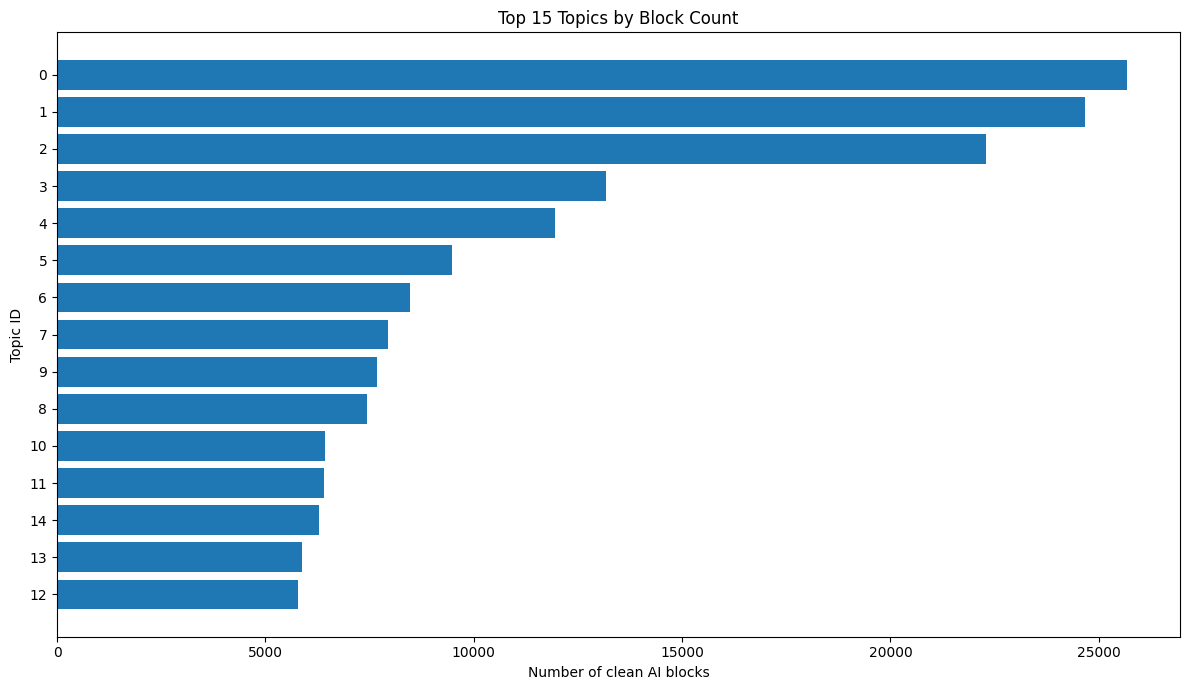

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/viz_topic_size_bar.png


In [24]:
plot_df = topic_summary[topic_summary["topic_id"] != -1].head(TOP_PLOT_TOPICS).copy()

plt.figure(figsize=(12, 7))
plt.barh(
    plot_df["topic_id"].astype(str)[::-1],
    plot_df["n_blocks"][::-1],
)
plt.xlabel("Number of clean AI blocks")
plt.ylabel("Topic ID")
plt.title(f"Top {TOP_PLOT_TOPICS} Topics by Block Count")
plt.tight_layout()
plt.savefig(TOPIC_SIZE_PNG, dpi=220, bbox_inches="tight")
plt.show()

print("wrote:", TOPIC_SIZE_PNG)

## Visualization — Topic Trends Over Time

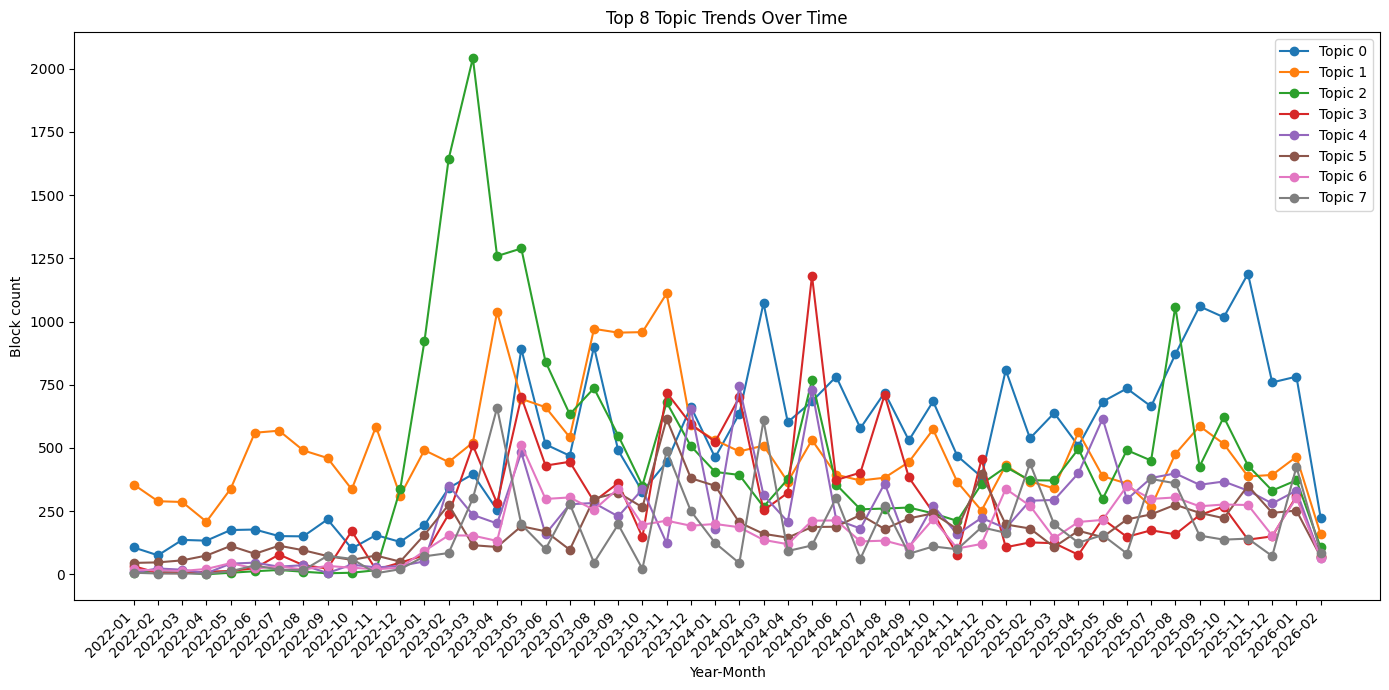

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/viz_topic_time_top_topics.png


In [25]:
top_time_topic_ids = (
    topic_summary.loc[topic_summary["topic_id"] != -1, "topic_id"]
    .head(TIME_TOP_TOPICS)
    .tolist()
)

time_plot = topic_time_panel[
    topic_time_panel["topic_id"].isin(top_time_topic_ids)
].copy()

if len(time_plot) > 0:
    pivot = time_plot.pivot_table(
        index="year_month",
        columns="topic_id",
        values="n_blocks",
        aggfunc="sum",
        fill_value=0,
    ).sort_index()

    plt.figure(figsize=(14, 7))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=f"Topic {col}")

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Block count")
    plt.xlabel("Year-Month")
    plt.title(f"Top {TIME_TOP_TOPICS} Topic Trends Over Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(TOPIC_TIME_PNG, dpi=220, bbox_inches="tight")
    plt.show()

    print("wrote:", TOPIC_TIME_PNG)
else:
    print("No topic-time data available for plotting.")

## Visualization — 2D UMAP Topic Scatter on Fit Sample

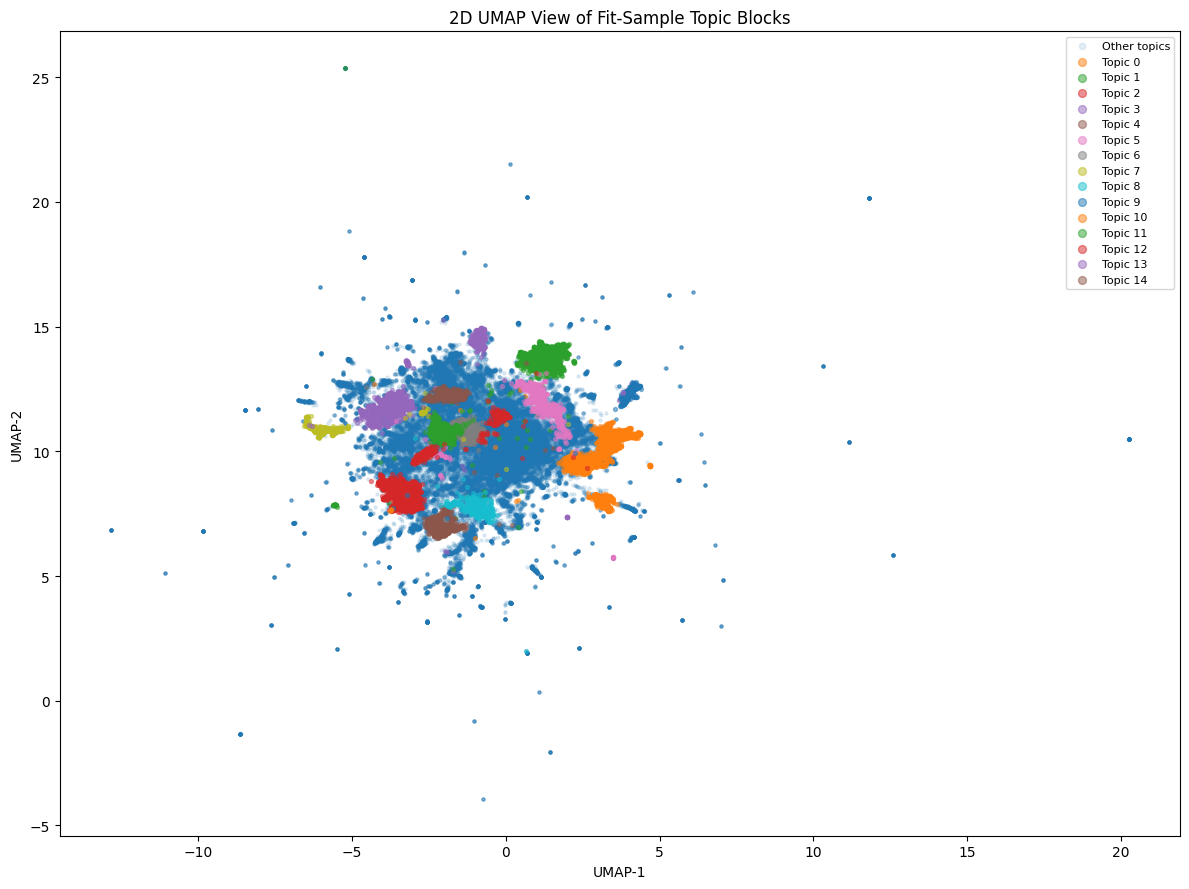

wrote: /content/drive/MyDrive/NLP_FINAL_PROJECT_Tom_Chen/output/03_topic_modeling/viz_topic_umap_scatter.png


In [26]:
umap_2d = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=2,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=SEED,
)

fit_emb_2d = umap_2d.fit_transform(fit_embeddings)

scatter_df = pd.DataFrame(
    {
        "x": fit_emb_2d[:, 0],
        "y": fit_emb_2d[:, 1],
        "topic_id": fit_blocks["topic_id"].to_numpy(),
    }
)

top_scatter_topics = set(
    topic_summary.loc[topic_summary["topic_id"] != -1, "topic_id"].head(TOP_PLOT_TOPICS).tolist()
)

scatter_df["plot_topic"] = scatter_df["topic_id"].where(
    scatter_df["topic_id"].isin(top_scatter_topics),
    other=-999,
)

plt.figure(figsize=(12, 9))

other = scatter_df[scatter_df["plot_topic"] == -999]
if len(other) > 0:
    plt.scatter(other["x"], other["y"], s=5, alpha=0.12, label="Other topics")

for t in sorted(set(scatter_df["plot_topic"].tolist())):
    if t == -999:
        continue
    sub = scatter_df[scatter_df["plot_topic"] == t]
    plt.scatter(sub["x"], sub["y"], s=8, alpha=0.50, label=f"Topic {t}")

plt.title("2D UMAP View of Fit-Sample Topic Blocks")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(TOPIC_SCATTER_PNG, dpi=220, bbox_inches="tight")
plt.show()

print("wrote:", TOPIC_SCATTER_PNG)

## Quick Readout

In [27]:
print("blocks_with_topics shape:", blocks_with_topics.shape)
print("docs_with_topic_distribution shape:", docs_with_topic_distribution.shape)
print("noise share:", float((blocks_with_topics["topic_id"] == -1).mean()))

print("\nLargest topics:")
display(topic_summary.head(15))

print("\nRepresentative blocks from largest non-noise topics:")
top_topic_ids = topic_summary.loc[topic_summary["topic_id"] != -1, "topic_id"].head(5).tolist()
display(
    representative_blocks[
        representative_blocks["topic_id"].isin(top_topic_ids)
    ].head(25)
)

blocks_with_topics shape: (585524, 16)
docs_with_topic_distribution shape: (271309, 9)
noise share: 0.4625361214911771

Largest topics:


,topic_id,n_blocks,n_docs,n_domains,topic_name,top_keywords,avg_topic_prob,avg_topic_text_len,is_noise_topic,human_label,super_topic,include_in_analysis,notes
0,0,25667,12974,1271,0_gpu_net_nvidia_intel,"gpu, net, nvidia, intel, dell, gaming, computi...",0.962727,963.547123,0,,,True,
1,1,24660,11026,1532,1_ai platform_device_providers_ai healthcare,"ai platform, device, providers, ai healthcare,...",0.865960,989.170762,0,,,True,
2,2,22287,12234,1991,2_ai chatbot_chatgpt plus_chatgpt ai_ai model,"ai chatbot, chatgpt plus, chatgpt ai, ai model...",0.894194,896.966034,0,,,True,
3,3,13174,5681,1480,3_ai generated content_ai generated images_dis...,"ai generated content, ai generated images, dis...",0.861556,776.295810,0,,,True,
4,4,11959,6182,1202,4_ai overviews_ai features_google ai_ai chatbot,"ai overviews, ai features, google ai, ai chatb...",0.897742,818.690024,0,,,True,
5,5,9467,5242,1334,5_smart_ai data centers_algorithm_prediction,"smart, ai data centers, algorithm, prediction,...",0.935163,1007.689764,0,,,True,
6,6,8469,4693,1192,6_ai skills_ai work_automated_automation,"ai skills, ai work, automated, automation, ai ...",0.916620,852.414453,0,,,True,
7,7,7950,4122,1074,7_ai chatbot_robot_ai company_media platform,"ai chatbot, robot, ai company, media platform,...",0.907356,870.711069,0,,,True,
8,9,7688,4307,1087,9_ai research_ai assistant_ai model_ai chatbot,"ai research, ai assistant, ai model, ai chatbo...",0.727940,942.506894,0,,,True,
9,8,7435,3188,818,8_free ai_ai powered video_ai image_options,"free ai, ai powered video, ai image, options, ...",0.826308,645.764492,0,,,True,



Representative blocks from largest non-noise topics:


,topic_id,rank_within_topic,doc_id,block_id,domain,date,title,topic_prob,clean_block_len,topic_text_len,clean_block_text_preview
0,0,1,156879,33,nasdaq.com,2026-01-29,Forget Intel: This AI Infrastructure Stock is ...,1.0,4999,4999,The Motley Fool-> Key PointsIntel stock soared...
1,0,2,46458,0,fool.ca,2024-07-10,This is the Best AI Stock to Buy Right Now | T...,1.0,4995,4995,Bank stocks represent partial ownership in a f...
2,0,3,195162,0,fool.ca,2024-01-10,Shopify Stock: A Big AI Moment in 2024? | The ...,1.0,4993,4993,Bank stocks represent partial ownership in a f...
3,0,4,73085,6,pehub.com,2023-12-21,Hg’s Alan Cline: ‘The AI revolution is real’; ...,1.0,4990,4990,Probably my favorite subject to cover has been...
4,0,5,110280,0,seekingalpha.com,2024-08-14,Can AI And Technology Stocks Keep On Keeping O...,1.0,4982,4982,Can AI And Technology Stocks Keep On Keeping O...
5,1,1,28999,1,alaskasnewssource.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4998,4998,"IntelligencePublished: Nov. 28, 2022 at 5:00 A..."
6,1,2,34069,1,wjhg.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4998,4998,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."
7,1,3,13112,1,ktre.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."
8,1,4,94503,1,wcax.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 9:00 A..."
9,1,5,95357,1,1011now.com,2022-11-28,Health systems in Pennsylvania and Kentucky Jo...,1.0,4997,4997,"IntelligencePublished: Nov. 28, 2022 at 8:00 A..."


## Topic Consolidation Strategy (Working Draft)

The BERTopic modeling step produced approximately 70+ topics from the cleaned corpus.  
Initial inspection of topic keywords, representative blocks, and topic distribution shows that the clustering quality is generally strong, but many topics represent closely related subthemes that can be consolidated for higher-level analysis.

Since the goal of this project is **to analyze how AI impacts industries and society**, the raw topic layer will serve as an intermediate representation. For downstream analysis (sentiment, trends, impact evaluation), topics will be **manually consolidated into a smaller set of interpretable super-topics**.

The consolidation follows an **industry- and impact-oriented taxonomy**, rather than a purely linguistic clustering structure.

### Proposed Super-Topic Structure

1. **AI Infrastructure & Compute**  
   Core hardware and computational foundations enabling AI systems.  
   Includes topics related to GPUs, chips, data centers, large-scale compute infrastructure, and cloud AI platforms.

2. **Consumer AI Interfaces**  
   AI products directly interacting with end users.  
   Includes chatbots, conversational agents, search integrations, personal AI assistants, and companion systems.

3. **Enterprise & Industry Adoption**  
   Deployment of AI in business environments and vertical industries.  
   Includes healthcare AI, fintech applications, enterprise platforms, workflow automation, coding copilots, and educational applications.

4. **Creative Media & Content Generation**  
   AI applications transforming creative industries and digital media.  
   Includes image/video generation, music generation, streaming media production, gaming AI, and broader generative content ecosystems.

5. **Governance, Regulation & Risk**  
   Policy, legal, and societal challenges associated with AI.  
   Includes AI regulation frameworks, cybersecurity, misinformation, copyright disputes, safety concerns, and broader societal risks.

6. **Frontier Research & Ecosystem**  
   The evolving technological frontier and AI innovation ecosystem.  
   Includes AGI discussions, frontier model research, startup ecosystems, industry conferences, and global AI development dynamics.

### Rationale

This structure aligns with the **analytical objective of the project**, which focuses on understanding AI's influence across technological infrastructure, consumer adoption, industry transformation, creative production, governance frameworks, and the broader innovation ecosystem.

Rather than presenting dozens of granular topics, this approach enables:

- clearer interpretation of topic clusters
- stable aggregation for sentiment and trend analysis
- coherent narrative structure for the final report and presentation

### Next Steps

With the high-level thematic structure defined, the next analytical phase will focus on **Named Entity Recognition (NER)** to identify key actors within the corpus, including:

- companies and organizations
- technology platforms
- government institutions
- public figures and researchers

Entity extraction will support downstream analyses such as:

- identifying leading companies in each AI domain
- mapping topic–entity relationships
- analyzing how specific actors influence AI discourse across industries